In [10]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt

from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.predictor.xwt import XWT

from bluemath_tk.core.io import load_model

In [ ]:
from pathlib import Path

# Daily ERA5 predictors (msl in hPa, msl_gradient in hPa^2, land = NaN) saved by
# toolkit/datamining/PCA_mslp.ipynb.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "toolkit" / "datamining").is_dir())
pca_path = repo_root / "toolkit" / "datamining" / "outputs"
region_id = "north_pacific_20N-60N_165W-105W"
predictors_file = pca_path / f"era5_msl_gradient_{region_id}_1979-2025_2deg_ocean.nc"
if not predictors_file.exists():
    raise FileNotFoundError(f"{predictors_file} not found. Run toolkit/datamining/PCA_mslp.ipynb first.")

with xr.open_dataset(predictors_file) as ds:
    era5 = ds[["msl", "msl_gradient"]].load()
era5

In [ ]:
pca_ob = load_model(str(pca_path / f"pca_msl_gradient_{region_id}_1979-2025_2deg_ocean.pkl"))

sort_var = pca_ob.vars_to_stack[0]
data_for_xwt = pca_ob.pcs.copy()
data_for_xwt[sort_var] = ("time", np.zeros(data_for_xwt.sizes["time"]))

In [ ]:
kma = KMA(num_clusters=36, seed=42)

xwt = XWT(steps={"pca": pca_ob, "kma": kma})
xwt.fit(
    data=era5,
    fit_params={
        "pca": {},
        "kma": {
            "normalize_data": False,
            "min_number_of_points": 25,
            "max_number_of_iterations": 100,
        },
    },
    variable_to_sort_bmus=sort_var,
)

xwt._exclude_attributes = []  # To save data used for fitting
# os.makedirs('outputs')
xwt.save_model("outputs/dwt_model.pkl")

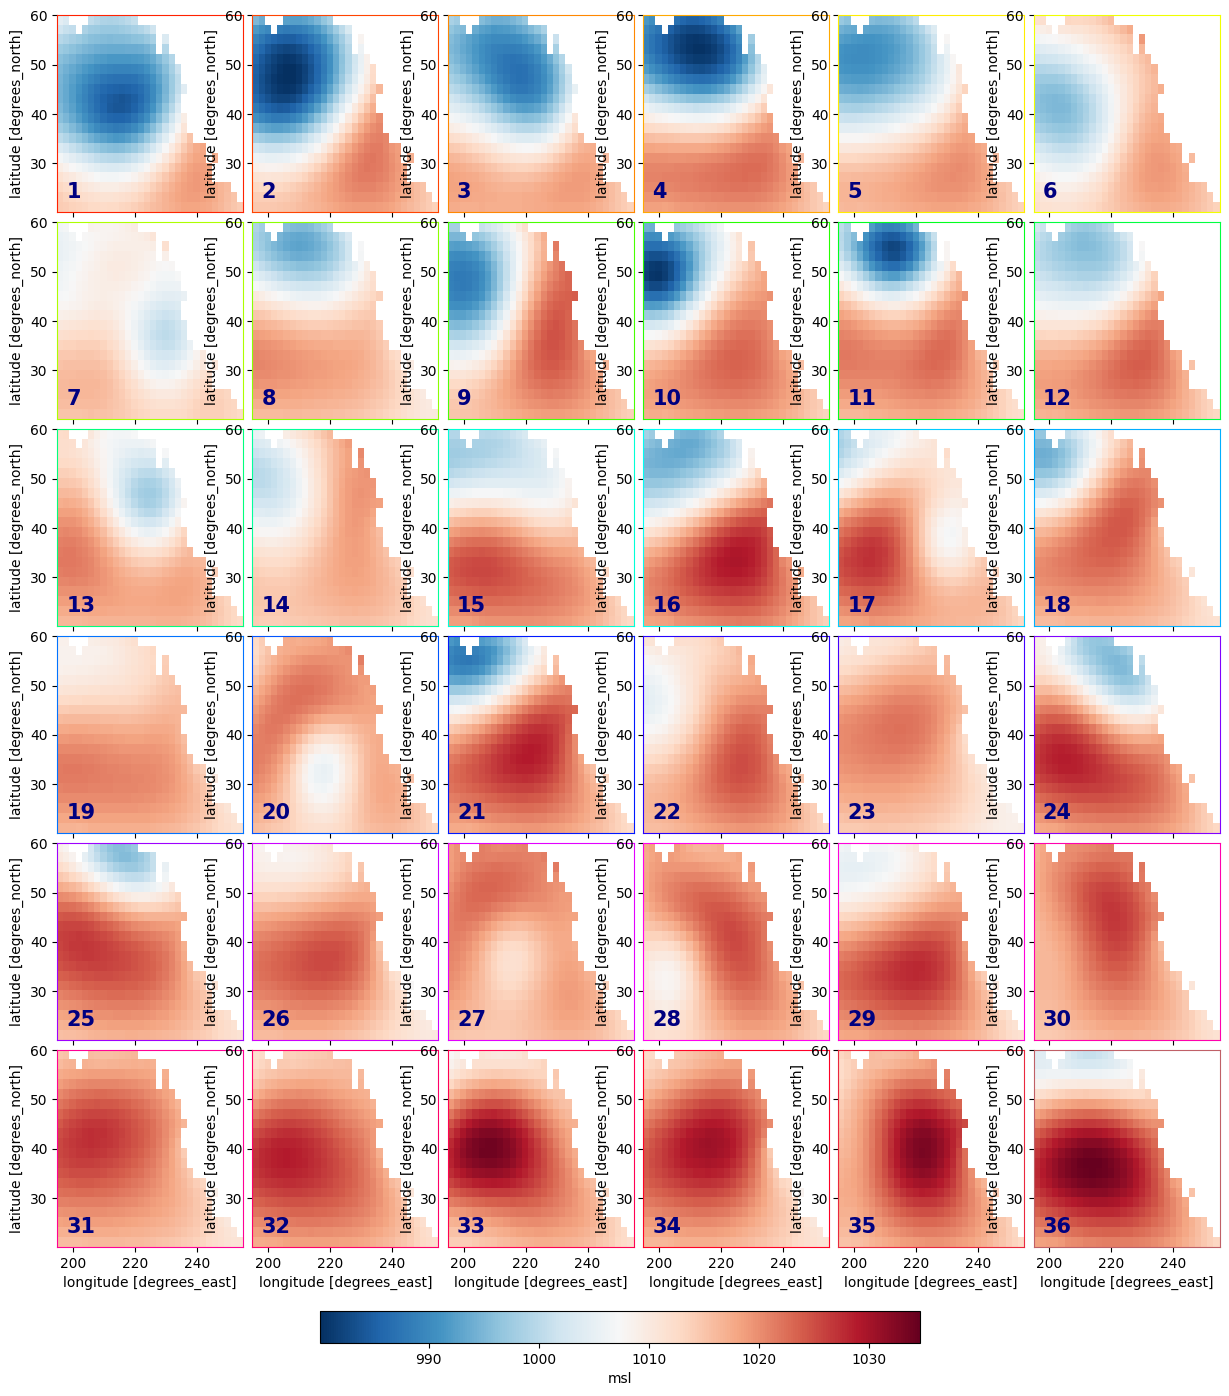

In [19]:
xwt.plot_xwts(var_to_plot='msl')

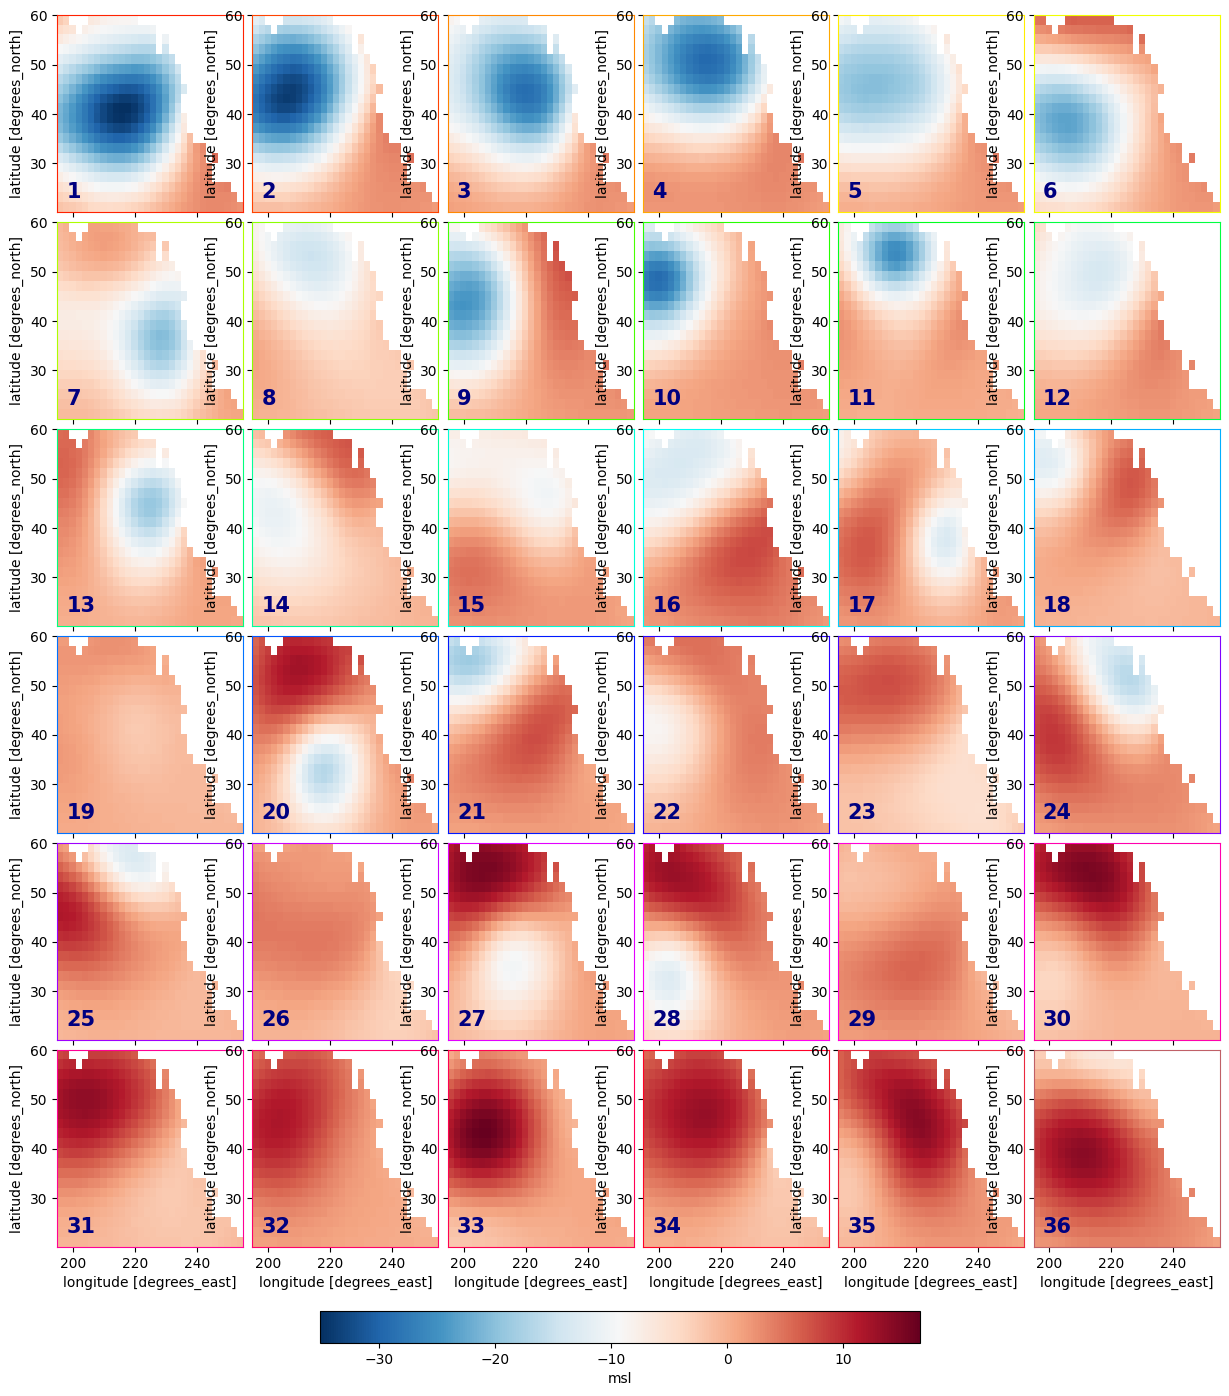

In [ ]:
xwt.plot_xwts(var_to_plot='msl', anomaly = True)

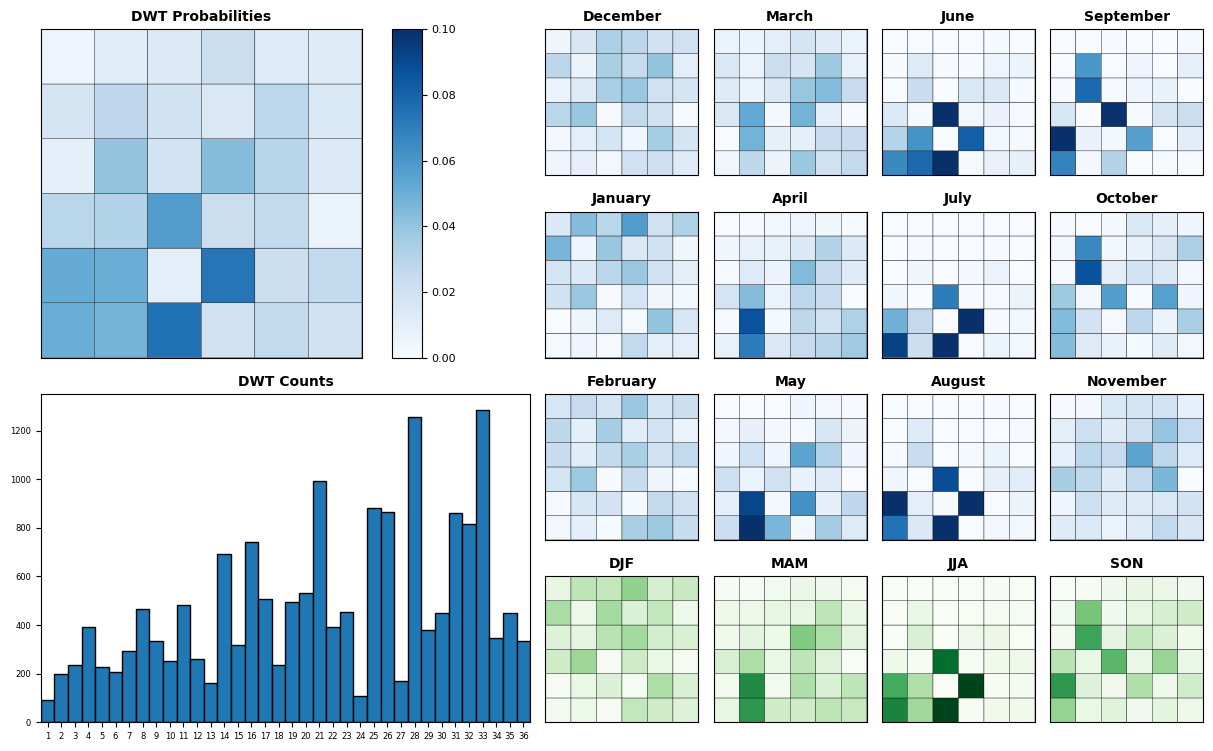

In [5]:
xwt.plot_dwts_probs()

In [6]:
xwt.kma_bmus

,kma_bmus
1979-01-01,13
1979-01-02,6
1979-01-03,6
1979-01-04,6
1979-01-05,6
...,...
2025-12-27,19
2025-12-28,7
2025-12-29,10
2025-12-30,23


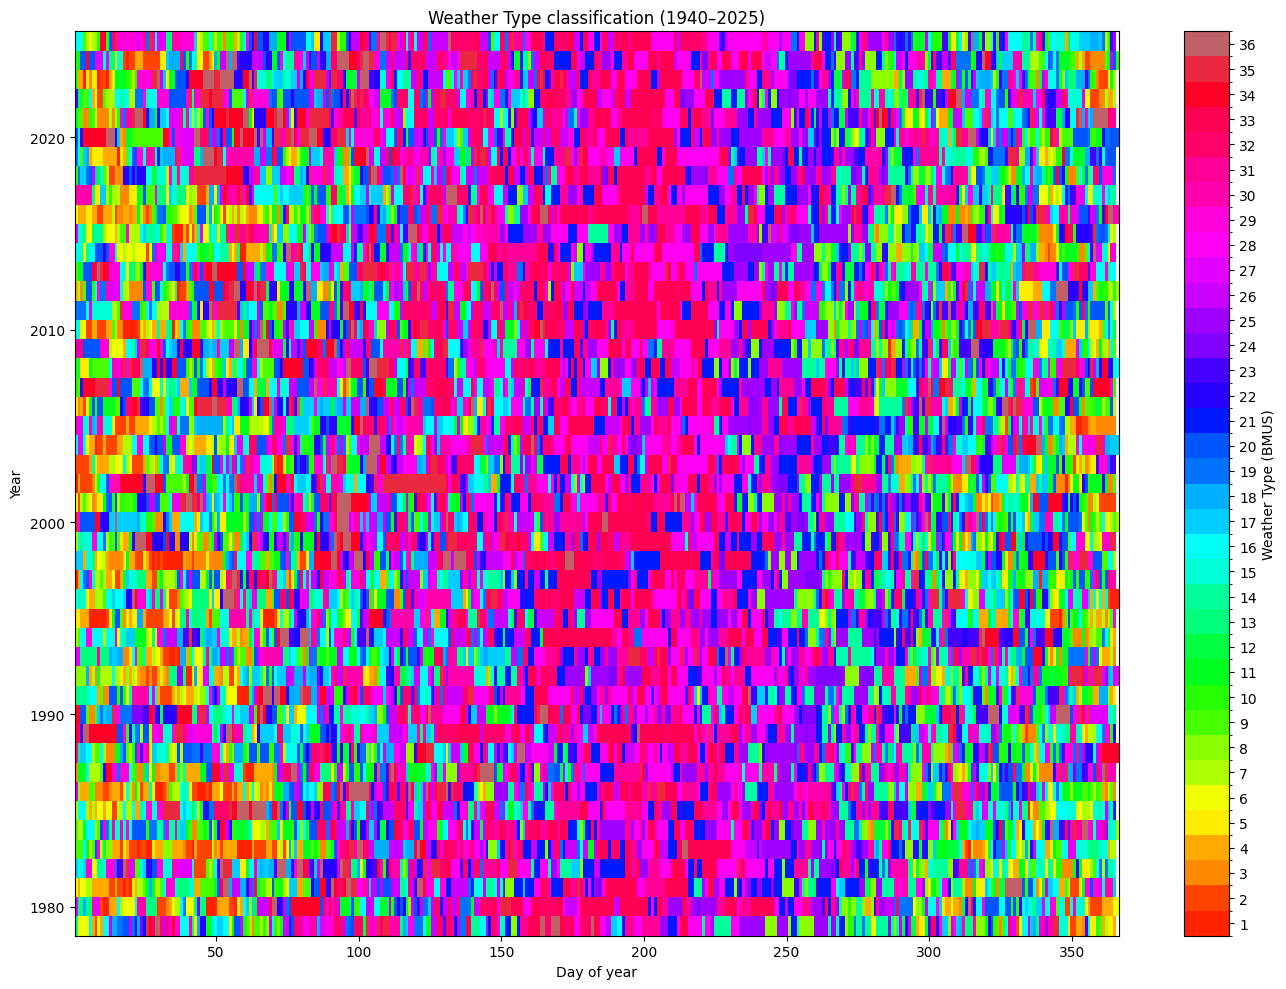

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

df = xwt.kma_bmus.copy()
df['year'] = df.index.year
df['doy'] = df.index.dayofyear

# Rejilla año x día-del-año
grid = df.pivot(index='year', columns='doy', values='kma_bmus')

# --- Paleta de 36 colores ---
# Intenta usar la paleta propia de BlueMath; si no la encuentras, usa un fallback categórico robusto

from bluemath_tk.teslakit.plotting.custom_colors import GetClusterColors
colors = GetClusterColors(36)

cmap = ListedColormap(colors)
bounds = np.arange(0.5, 37.5, 1)   # centra cada entero 1..36 en su propio color
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap=cmap, norm=norm, shading='auto')

ax.set_xlabel('Day of year')
ax.set_ylabel('Year')
ax.set_title('Weather Type classification (1940–2025)')

cbar = fig.colorbar(im, ax=ax, ticks=range(1, 37))
cbar.set_label('Weather Type (BMUS)')

plt.tight_layout()
plt.show()

<Axes: >

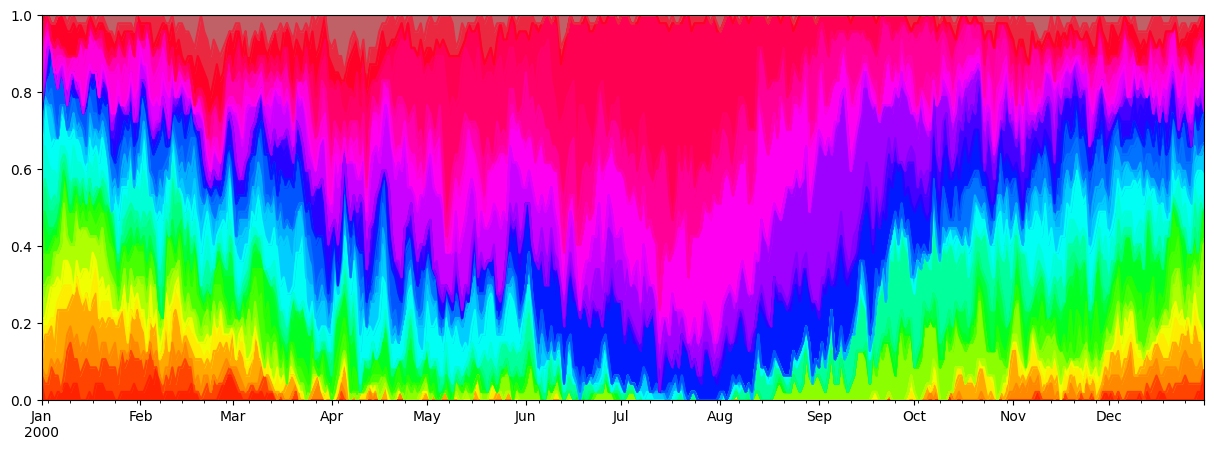

In [8]:
xwt.plot_perpetual_year()